### ✅ 섹션 6 수행내역 캡쳐
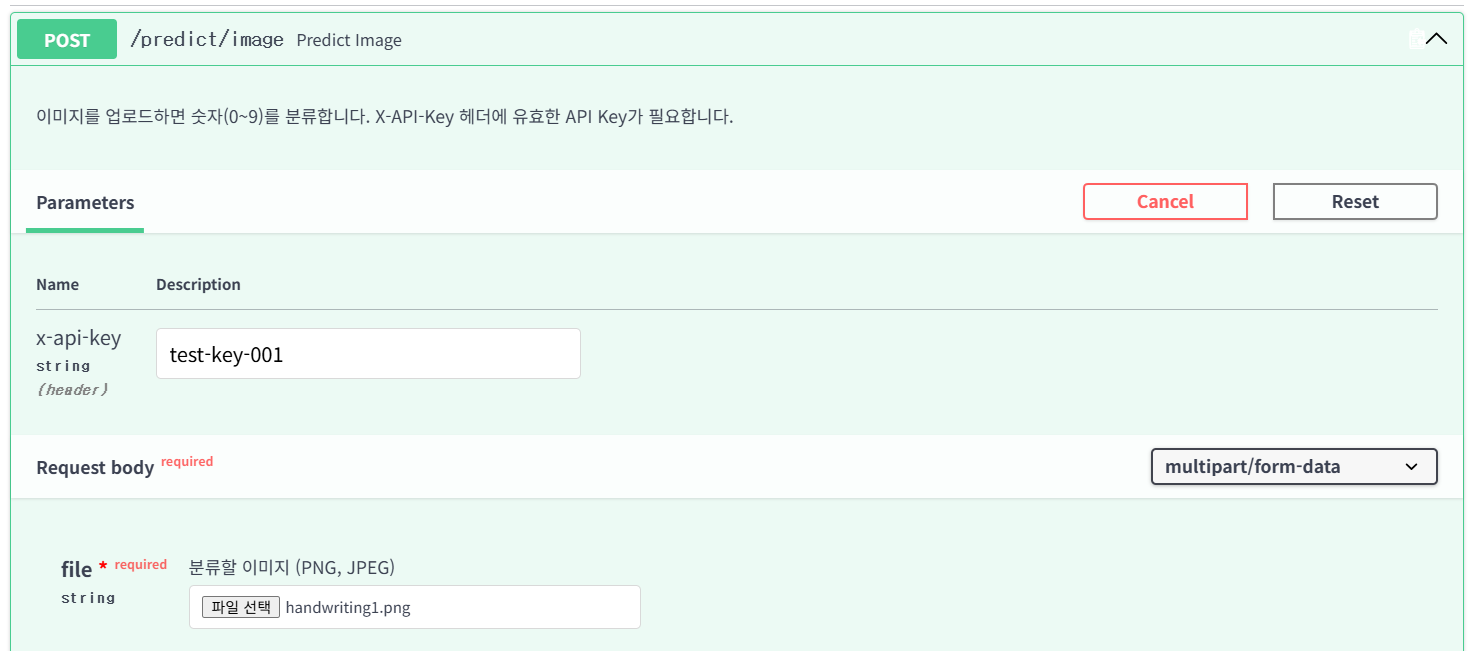

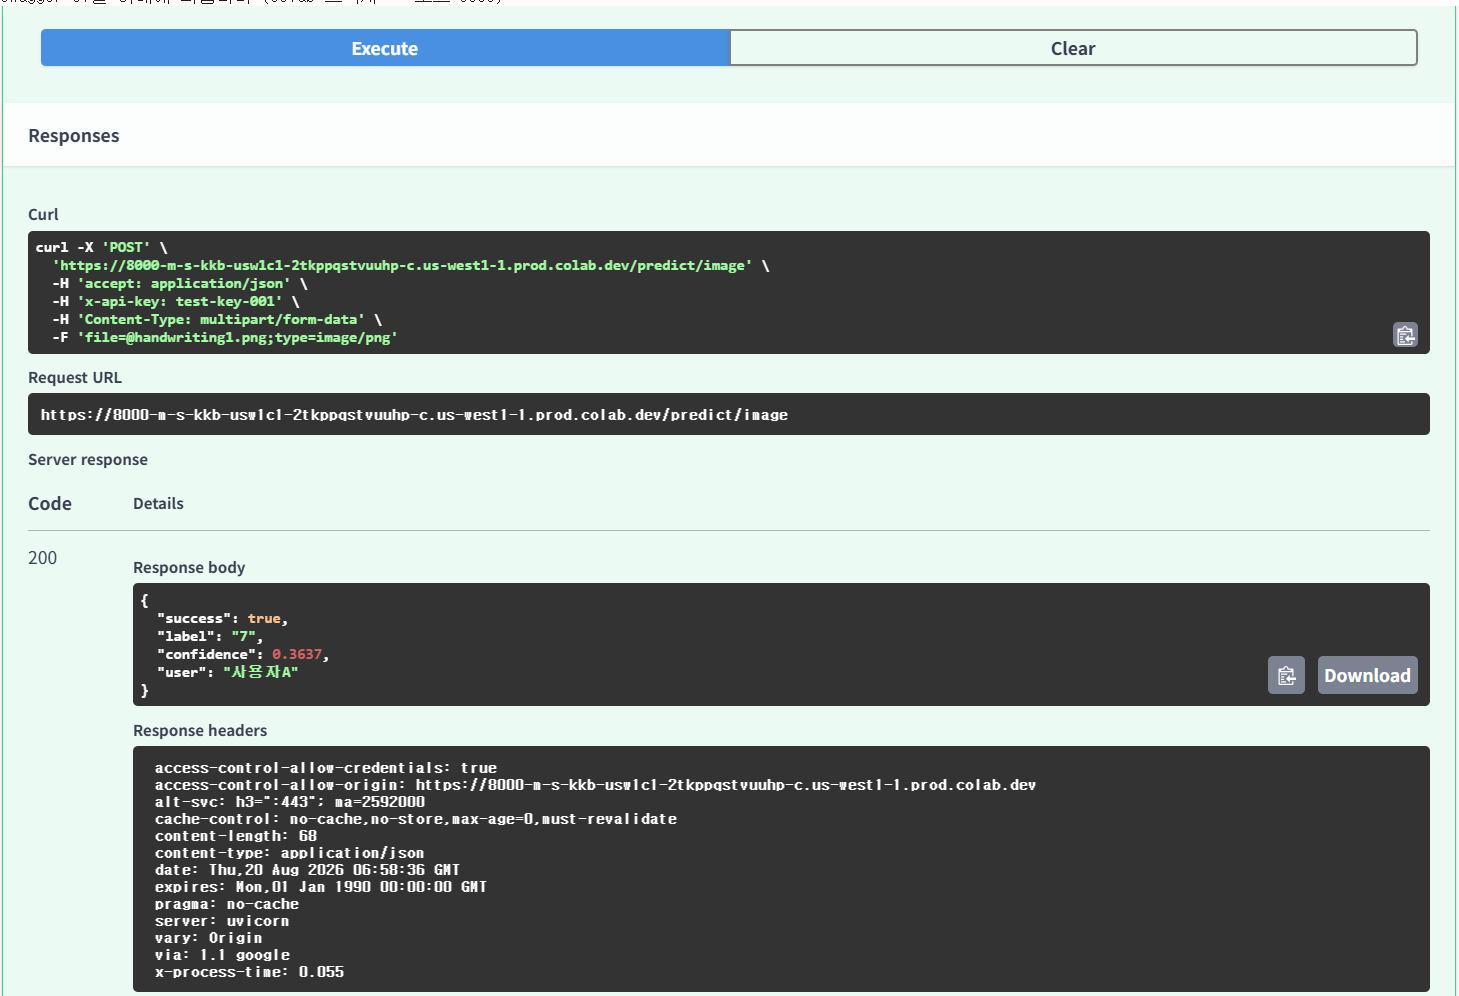

### ✅ 체크포인트 01

1. 인증 없는 API가 위험한 이유를 두 가지 이상 설명하세요.
    *   **서버 다운/과부하:** 악의적인 사용자가 무한 요청을 보내 서버를 마비시키거나 과부하시켜 정상적인 서비스 제공을 방해할 수 있습니다.
    *   **비용 폭탄:** 클라우드 환경에서 불필요한 요청으로 인해 GPU/CPU 사용량이 급증하여 예상치 못한 과금이 발생할 수 있습니다.
    *   **모델 도용:** 공격자가 대량의 입력-출력 쌍을 수집하여 모델을 모방하거나 역설계할 수 있습니다.
    *   **추적 불가:** 에러 발생 시 누가 어떤 요청을 보냈는지 파악하기 어려워 문제 원인 분석 및 악성 사용자 차단이 어렵습니다.
2. API Key 방식이 ML 추론 API에 적합한 이유는 무엇입니까?
    *   **간편한 인증:** ML 추론 API는 일반적으로 사용자 로그인과 같은 복잡한 인증 절차가 필요 없으므로, API Key 방식이 구현 및 사용이 간편합니다.
    *   **인증 및 사용량 추적 용이:** 단일 키로 요청에 대한 인증과 사용자별 사용량 추적을 동시에 관리할 수 있어 운영 효율성이 높습니다.

### ✅ 체크포인트 02

1. `Header(None)`에서 `None`은 어떤 상황에서 `x_api_key`에 들어갑니까?

   **답변:** `x_api_key`에 `None`이 들어가는 경우는 클라이언트가 HTTP 요청 헤더에 `X-API-Key`를 전혀 포함하지 않았을 때입니다.
2. `Depends(verify_api_key)`를 엔드포인트에 추가하면 요청 처리 흐름이 어떻게 바뀝니까?

   **답변:** `Depends(verify_api_key)`를 엔드포인트에 추가하면, 클라이언트의 요청이 엔드포인트 함수(`predict_image` 등)에 도달하기 전에 `verify_api_key` 함수가 먼저 실행됩니다. `verify_api_key` 함수가 성공적으로 실행되면 그 반환값(`"사용자A"`와 같은)이 엔드포인트 함수의 `user` 파라미터로 주입됩니다. 만약 `verify_api_key` 함수가 `HTTPException`을 발생시키면, 엔드포인트 함수는 실행되지 않고 해당 `HTTPException`이 클라이언트에게 반환됩니다.
3. 인증 실패 시 반환하는 HTTP 상태 코드 401의 의미는 무엇입니까?

   **답변:** HTTP 상태 코드 401 (Unauthorized)은 클라이언트가 요청한 리소스에 대한 유효한 인증 자격 증명(authentication credentials)이 없거나 제공되었지만 유효하지 않음을 나타냅니다. 즉, 요청은 유효하지만, 요청을 보낸 사용자가 누구인지 확인이 안 되거나, 확인할 수 없는 사용자(또는 권한이 없는 사용자)이므로 요청된 동작을 수행할 수 없다는 의미입니다.

### ✅ 체크포인트 03

1. `UploadFile`과 Base64 방식의 핵심 차이는 무엇입니까?

   **답변:** `UploadFile`은 파일을 독립적인 `multipart/form-data` 형식으로 직접 전송하는 방식입니다. 이는 Swagger UI에서 파일 선택 버튼을 제공하여 테스트가 편리하며, 대용량 파일 전송에 효율적입니다. 반면, Base64 방식은 이미지를 텍스트 문자열로 인코딩하여 JSON 데이터의 일부로 전송하는 방식입니다. 이는 주로 다른 JSON 데이터와 함께 이미지를 하나의 요청에 담을 때 사용되지만, 파일 크기가 커질수록 오버헤드가 증가하고 처리 과정이 복잡해질 수 있습니다.
2. `file.content_type`으로 타입을 검증하는 이유는 무엇입니까?

   **답변:** `file.content_type`으로 타입을 검증하는 것은 클라이언트가 보낸 파일의 MIME 타입을 확인하여, `text/plain`과 같이 명백히 허용되지 않는 파일 형식을 1차적으로 걸러내기 위함입니다. 그러나 이 값은 클라이언트 측에서 설정되므로 위조될 수 있습니다. 따라서 `.exe` 파일을 `.png`로 위장하는 경우 이 단계는 통과할 수 있으며, 실제 이미지 디코딩 검증(`PIL.Image.open`) 단계에서 최종적으로 걸러집니다.
3. 파일 크기를 제한하지 않으면 어떤 문제가 발생할 수 있습니까?

   **답변:** 파일 크기를 제한하지 않으면 다음과 같은 문제가 발생할 수 있습니다:
    *   **서버 리소스 고갈:** 클라이언트가 매우 큰 파일을 업로드할 경우, 서버의 메모리(RAM)나 디스크 공간이 과도하게 사용되어 서버가 다운되거나 다른 요청 처리에 지연이 발생할 수 있습니다.
    *   **서비스 거부 공격(DoS):** 악의적인 사용자가 의도적으로 초대형 파일을 계속 업로드하여 서버 자원을 소모시켜 정상적인 서비스 운영을 방해할 수 있습니다.
    *   **느린 응답 시간:** 대용량 파일의 업로드 및 처리는 네트워크 대역폭과 서버 CPU를 많이 소모하여, 다른 클라이언트의 요청에 대한 응답 시간을 지연시킬 수 있습니다.

### ✅ Day 6 최종 체크포인트


**Q1. API Key 인증이 없으면 어떤 위험이 있습니까? (두 가지 이상)**

*   **서버 다운/비용 폭탄:** 악의적인 사용자나 실수로 인한 대량 요청으로 서버 자원이 고갈되어 서비스 마비 또는 클라우드 비용 폭탄이 발생할 수 있습니다.
*   **모델 도용/추적 불가:** 모델의 입력-출력 쌍을 대량으로 수집하여 모델을 모방하거나, 문제 발생 시 누가 어떤 요청을 보냈는지 추적하기 어려워집니다.

**Q2. Depends(verify_api_key)는 엔드포인트 실행 전에 어떤 일을 합니까?**

*   `Depends(verify_api_key)`는 엔드포인트 함수(`predict_image` 등)가 실행되기 전에 `verify_api_key` 함수를 먼저 실행합니다. `verify_api_key`가 성공하면 그 반환값(예: 사용자 이름)을 엔드포인트 함수의 해당 파라미터(예: `user`)에 주입합니다. 만약 `verify_api_key`가 `HTTPException`을 발생시키면, 엔드포인트 함수는 실행되지 않고 해당 `HTTPException`이 클라이언트에게 반환됩니다.

**Q3. UploadFile 방식이 Base64보다 편리한 점은 무엇입니까?**

*   `UploadFile`은 Swagger UI에서 파일 선택 버튼이 자동으로 제공되어 테스트가 매우 편리합니다. 파일을 직접 `multipart/form-data` 형태로 전송하므로 대용량 파일 전송에 더 효율적이며, 별도의 인코딩/디코딩 과정 없이 파일 자체를 다룰 수 있습니다.

**Q4. 파일 업로드 시 크기 제한을 하지 않으면 어떤 문제가 생깁니까?**

*   **서버 리소스 고갈:** 초대형 파일이 업로드될 경우 서버의 메모리나 디스크 공간이 과도하게 사용되어 서버 다운이나 다른 서비스에 영향을 줄 수 있습니다.
*   **서비스 거부 공격(DoS):** 악의적인 사용자가 대량의 파일을 지속적으로 업로드하여 서버 자원을 소모시키고 정상적인 서비스 운영을 방해할 수 있습니다.
*   **네트워크 대역폭 소모:** 불필요한 대용량 파일 업로드로 인해 네트워크 대역폭이 낭비되어 전체적인 서비스 응답 속도가 저하될 수 있습니다.

**Q5. 이미지를 28x28 그레이스케일로 변환하는 이유는 무엇입니까?**

*   모델의 **입력 요구사항을 충족**하기 위함입니다. MNIST 숫자 분류 모델은 일반적으로 28x28 픽셀 크기의 단일 채널(그레이스케일) 이미지를 입력으로 받도록 학습됩니다. 어떤 크기나 색상의 이미지가 들어오더라도 모델이 처리할 수 있는 표준화된 형식으로 변환하여 모델의 안정적인 추론을 보장합니다.